# Setup

In [49]:
import numpy as np
import matplotlib.pyplot as plt 

# Process time series data from tracking algorithm

* normalize
* detrend (which degree?)
* smooth 
* FFT
* convert to period

In [50]:
data = np.load("../data/220516_No contraction videos.npy")
data.shape

(10, 1208)

In [51]:
def process(data, norm=True, detrend=True, degree=6, smooth=True, smooth_n=20):
    if norm:
        # normalize time series
        mean = np.mean(data,axis=1).reshape(-1,1)
        std = np.std(data,axis=1).reshape(-1,1)
        data = (data-mean)/std
    
    # detrend data
    trend = np.zeros(data.shape)
    if detrend:
        for i in range(data.shape[0]):
            x = np.linspace(0, data[0,:].shape[0], data[0,:].shape[0])
            y = data[i,:]
            model = np.polyfit(x, y, degree)
            trend[i,:] = np.polyval(model, x)
            
    data_detrend = data - trend
    if smooth:
        n=20
        data_smooth = np.zeros((data_detrend.shape[0], data_detrend.shape[1]-(n-1)))
        for i in range(data_detrend.shape[0]):
            data_smooth[i,:] = np.convolve(data_detrend[i,:], np.ones(n)/n, mode='valid')
    else:
        data_smooth = data_detrend
    
    # window function for fft
    hann_s = np.hanning(data_smooth.shape[1])
    # multiply window function with time series
    signal_hann = data_smooth*hann_s
    # fft
    N = int(data_smooth.shape[1]/2) + 1
    y_hann = np.zeros(signal_hann.shape)
    #y_hann_plot = np.zeros(signal_hann[i,:N].shape)
    for i in range(data_smooth.shape[0]):
        y_hann[i,:] = np.fft.fft(signal_hann[i,:])
        #y_hann_plot[i,:]= 2.0*np.abs(y_hann[i,:N])/N
    
    # convert to period
    fa = 1
    X = np.linspace(0, fa/2, N, endpoint=True)
    Xp = 1.0/X 
    return data, trend, data_detrend, data_smooth, y_hann, X, Xp #y_hann_plot

In [52]:
data, trend, data_detrend, data_smooth, y_hann, X, Xp = process(data, norm=True, detrend=True, degree=6, smooth=True, smooth_n=20)

<ipython-input-51-6a27aa3eb3d7>:35: ComplexWarning: Casting complex values to real discards the imaginary part
  y_hann[i,:] = np.fft.fft(signal_hann[i,:])
<ipython-input-51-6a27aa3eb3d7>:41: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


# Plots

In [53]:
# trend


# fft as period

In [54]:
data.shape, trend.shape, data_smooth.shape, y_hann.shape

((10, 1208), (10, 1208), (10, 1189), (10, 1189))

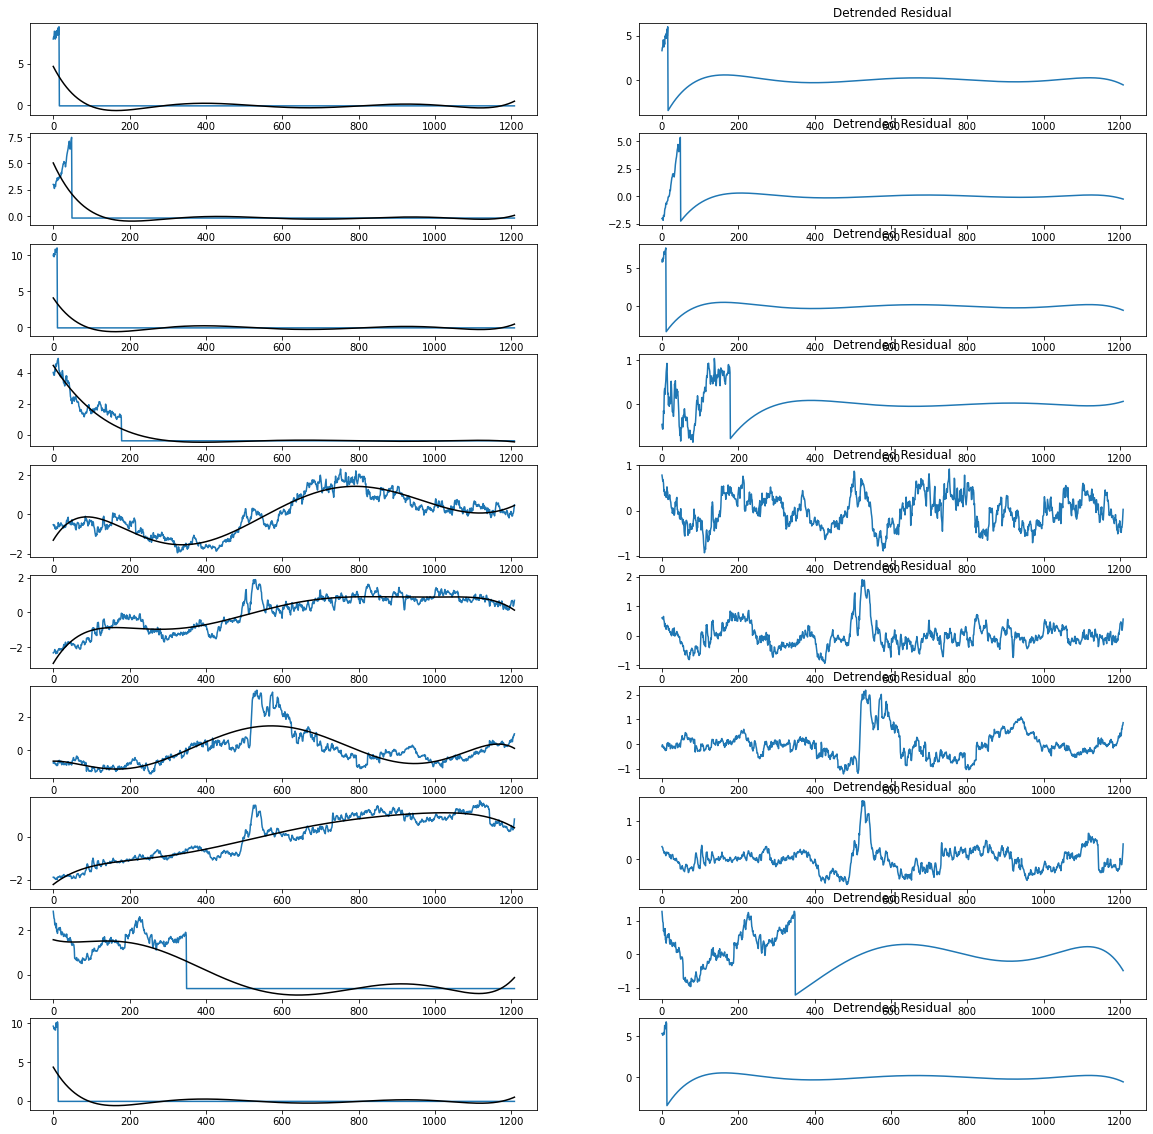

In [55]:
# data: normalized and detrended time series
fig, axis = plt.subplots(10, 2, figsize=(20,20))
x = np.linspace(0, data[0,:].shape[0], data[0,:].shape[0])
for i, ax in enumerate(axis):
    axis[i,0].plot(x, data[i,:])
    axis[i,0].plot(x, trend[i,:], 'k-')
    
    axis[i,1].plot(x, data[i,:] - trend[i,:])
    axis[i,1].set(title='Detrended Residual')

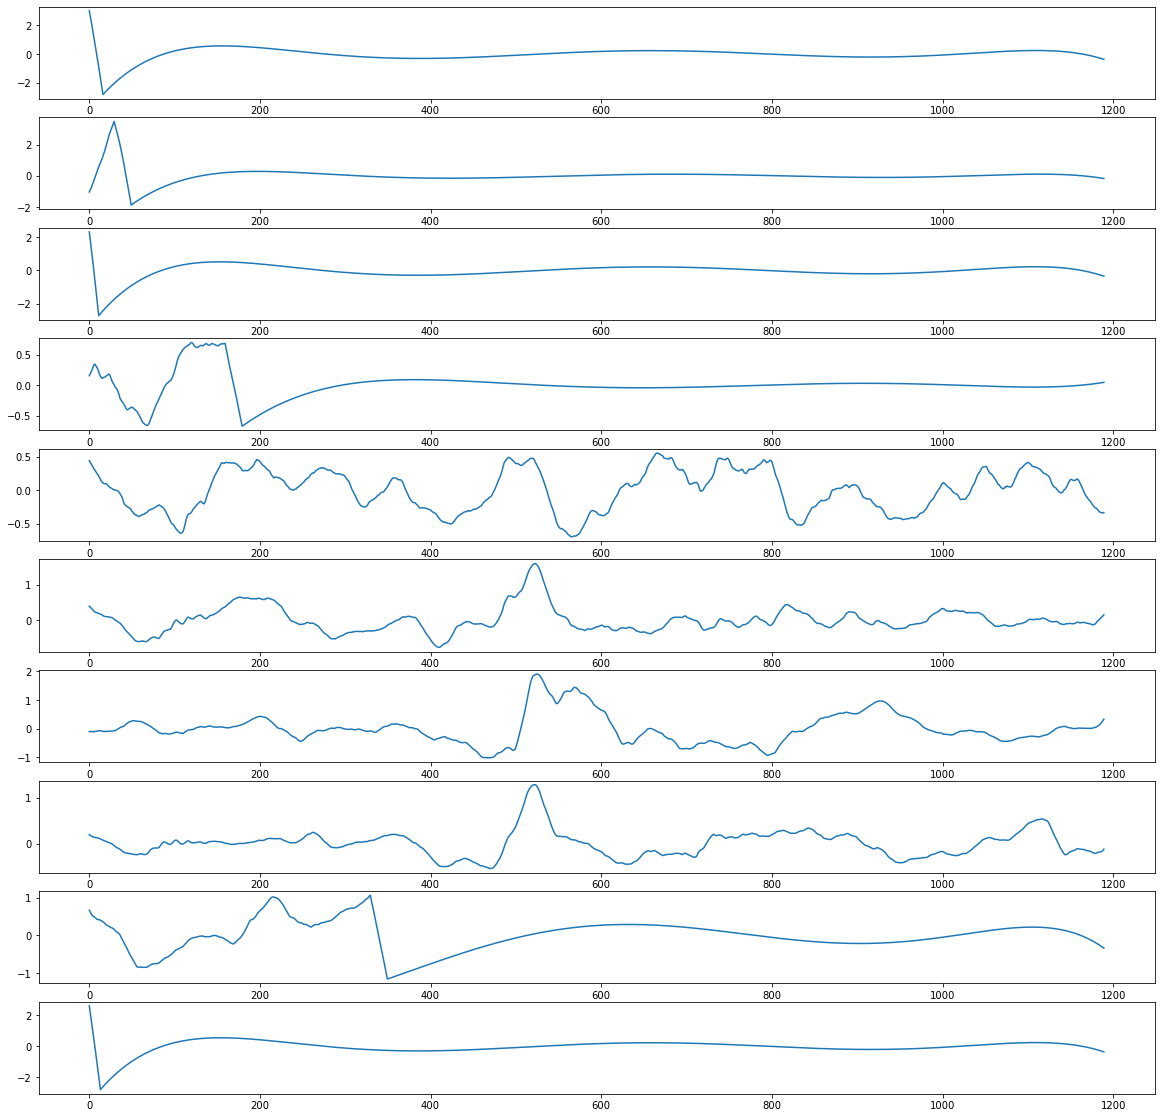

In [56]:
# data_smooth: running mean applied
fig, axis = plt.subplots(10, 1, figsize=(20,20))
x = np.linspace(0, data_smooth[0,:].shape[0], data_smooth[0,:].shape[0])
for i, ax in enumerate(axis):
    axis[i].plot(x, data_smooth[i,:])

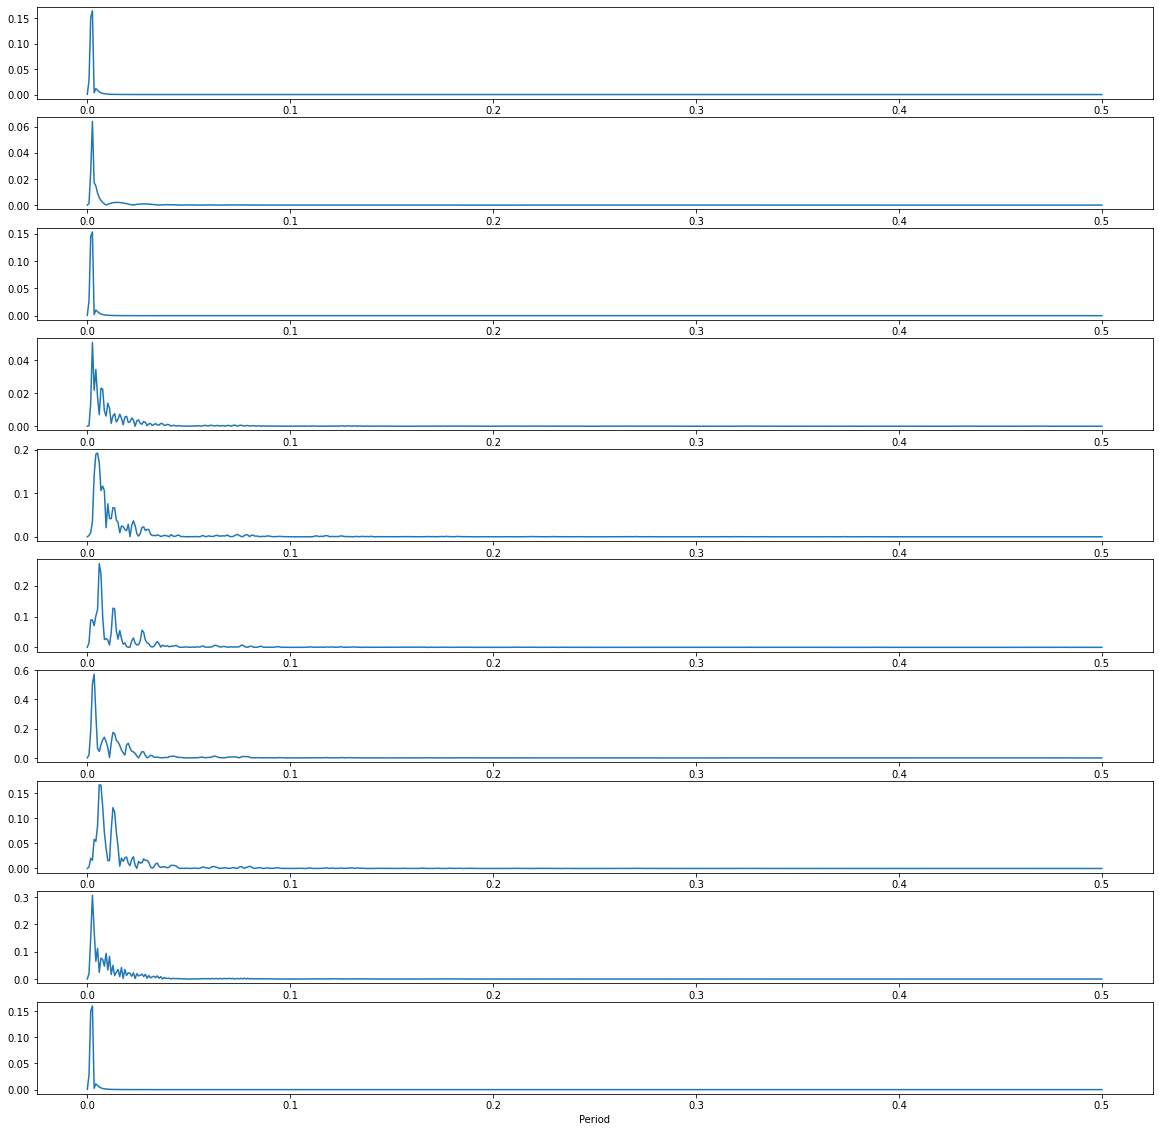

In [60]:
# fft
N = int(data_smooth.shape[1]/2) + 1
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    ax.plot(X, 2.0*np.abs(y_hann[i,:N])/N)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Period')

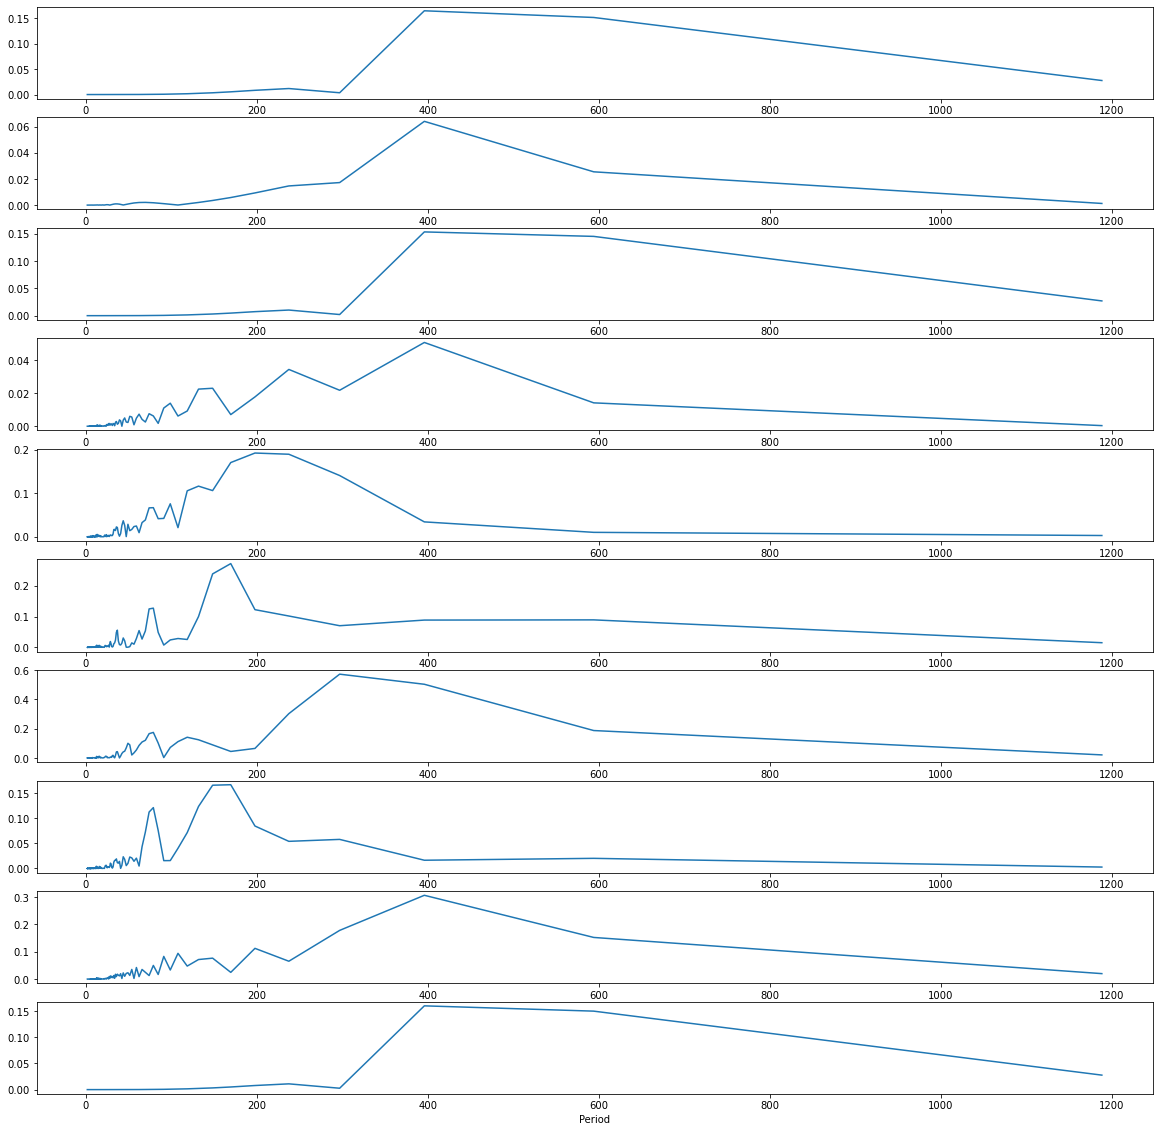

In [61]:
# fft period instead of frequence
N = int(data_smooth.shape[1]/2) + 1
fig, axis = plt.subplots(10, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    ax.plot(Xp, 2.0*np.abs(y_hann[i,:N])/N)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Period')